实验一：多分支执行  
目标：理解 add_conditional_edges 如何在运行时选择路径  
打印：每个节点的执行顺序和时间戳

In [45]:
from langgraph.graph import StateGraph, END
from langchain_core.runnables import RunnableConfig
from typing import TypedDict, Annotated, Literal
import operator
import time
from datetime import datetime
import threading

In [4]:
# State 定义
class BranchState(TypedDict):
    input: str
    route_decision: str          # 路由决策
    execution_log: Annotated[list, operator.add]  # Reducer：追加日志
    result: str

In [5]:
# 工具函数：统一的日志打印
def log(node_name: str, message: str, state: dict = None):
    ts = time.strftime("%H:%M:%S")
    print(f"  [{ts}] 🔵 {node_name:20s} │ {message}")
    return {"node": node_name, "message": message, "time": ts}

In [6]:
def entry_node(state: BranchState, config: RunnableConfig) -> dict:
    """入口节点：分析输入，决定走哪条路"""
    entry = log("entry_node", f"收到输入: '{state['input']}'，开始分析路由")
    
    # 简单的路由逻辑
    text = state["input"].lower()
    if "紧急" in text or "urgent" in text:
        decision = "urgent"
    elif "查询" in text or "query" in text:
        decision = "query"
    else:
        decision = "normal"
    
    log("entry_node", f"路由决策 → '{decision}'")
    
    return {
        "route_decision": decision,
        "execution_log": [entry],
    }

In [16]:
def urgent_node(state: BranchState, config: RunnableConfig) -> dict:
    """紧急分支：高优先级处理"""
    entry = log("urgent_node", "🚨 进入紧急处理路径")
    time.sleep(0.5)  # 模拟处理
    done = log("urgent_node", "紧急处理完成")
    return {
        "result": f"[紧急处理] 已优先处理: {state['input']}",
        "execution_log": [entry, done],
    }

In [17]:
def query_node(state: BranchState, config: RunnableConfig) -> dict:
    """查询分支：数据库查询"""
    entry = log("query_node", "🔍 进入查询处理路径")
    time.sleep(0.5)
    done = log("query_node", "查询完成")
    return {
        "result": f"[查询结果] 找到相关数据: {state['input']}",
        "execution_log": [entry, done],
    }

In [18]:
def normal_node(state: BranchState, config: RunnableConfig) -> dict:
    """普通分支：常规处理"""
    entry = log("normal_node", "📝 进入普通处理路径")
    time.sleep(0.5)
    done = log("normal_node", "普通处理完成")
    return {
        "result": f"[普通处理] 已处理: {state['input']}",
        "execution_log": [entry, done],
    }

In [19]:
def output_node(state: BranchState, config: RunnableConfig) -> dict:
    """汇总节点：所有分支最终都到这里"""
    entry = log("output_node", f"汇总结果: {state['result']}...")
    return {"execution_log": [entry]}

In [11]:
def route_decision(state: BranchState) -> Literal["urgent", "query", "normal"]:
    """
    路由函数：根据 state 决定下一个节点
    注意：这个函数不是节点，不接收 config，不修改 state
    它只是一个【决策函数】
    """
    return state["route_decision"]

In [12]:
# 构建 Graph
def build_branch_graph() -> StateGraph:
    builder = StateGraph(BranchState)
    
    # 添加节点
    builder.add_node("entry",  entry_node)
    builder.add_node("urgent", urgent_node)
    builder.add_node("query",  query_node)
    builder.add_node("normal", normal_node)
    builder.add_node("output", output_node)
    
    # 入口
    builder.set_entry_point("entry")
    
    # ★ 条件路由：entry 执行后，根据 route_decision 选择分支
    builder.add_conditional_edges(
        "entry",          # 从这个节点出发
        route_decision,   # 调用这个函数决定方向
        {
            "urgent": "urgent",   # 返回 "urgent" → 去 urgent 节点
            "query":  "query",    # 返回 "query"  → 去 query 节点
            "normal": "normal",   # 返回 "normal" → 去 normal 节点
        }
    )
    
    # 三条分支都汇向 output
    builder.add_edge("urgent", "output")
    builder.add_edge("query",  "output")
    builder.add_edge("normal", "output")
    builder.add_edge("output", END)
    
    return builder.compile()

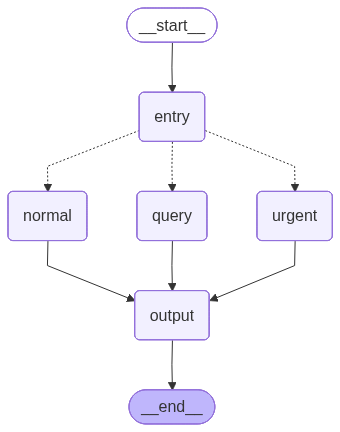

In [13]:
from IPython.display import display, Image
graph = build_branch_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
# 运行实验

def run_experiment_1():
    print("\n" + "═"*60)
    print("  实验一：多分支执行")
    print("═"*60)
    
    graph = build_branch_graph()
    
    test_cases = [
        "紧急：服务器宕机",
        "查询：用户订单状态",
        "帮我写一首诗",
    ]
    
    for text in test_cases:
        print(f"\n▶ 输入: '{text}'")
        print("  " + "-"*40)
        
        result = graph.invoke({
            "input": text,
            "route_decision": "",
            "execution_log": [],
            "result": "",
        })
        
        print(f"\n  最终结果: {result['result']}")
        print(f"  执行了 {len(result['execution_log'])} 个日志条目")



In [20]:
run_experiment_1()


════════════════════════════════════════════════════════════
  实验一：多分支执行
════════════════════════════════════════════════════════════

▶ 输入: '紧急：服务器宕机'
  ----------------------------------------
  [17:17:02] 🔵 entry_node           │ 收到输入: '紧急：服务器宕机'，开始分析路由
  [17:17:02] 🔵 entry_node           │ 路由决策 → 'urgent'
  [17:17:02] 🔵 urgent_node          │ 🚨 进入紧急处理路径
  [17:17:03] 🔵 urgent_node          │ 紧急处理完成
  [17:17:03] 🔵 output_node          │ 汇总结果: [紧急处理] 已优先处理: 紧急：服务器宕机...

  最终结果: [紧急处理] 已优先处理: 紧急：服务器宕机
  执行了 4 个日志条目

▶ 输入: '查询：用户订单状态'
  ----------------------------------------
  [17:17:03] 🔵 entry_node           │ 收到输入: '查询：用户订单状态'，开始分析路由
  [17:17:03] 🔵 entry_node           │ 路由决策 → 'query'
  [17:17:03] 🔵 query_node           │ 🔍 进入查询处理路径
  [17:17:03] 🔵 query_node           │ 查询完成
  [17:17:03] 🔵 output_node          │ 汇总结果: [查询结果] 找到相关数据: 查询：用户订单状态...

  最终结果: [查询结果] 找到相关数据: 查询：用户订单状态
  执行了 4 个日志条目

▶ 输入: '帮我写一首诗'
  ----------------------------------------
  [17:17:03] 🔵 entry_node    

---

实验二：Fan-out（扇出）  
目标：理解一个节点如何"广播"触发多个并行节点  
关键：多个节点在【同一个 SuperStep】中执行，读取【相同的 state 快照】  

---

In [21]:
class FanoutState(TypedDict):
    # 输入（只读，不会被并行节点修改）
    raw_text: str
    
    analysis_results: Annotated[list, operator.add]   # 分析结果（追加）
    warnings: Annotated[list, operator.add]           # 警告列表（追加）
    enrichments: Annotated[list, operator.add]        # 丰富数据（追加）
    
    # 执行追踪
    execution_log: Annotated[list, operator.add]
    
    # 最终汇总（merge_node 写入，此时没有并发）
    final_report: str

In [37]:
def entry_fanout(state: FanoutState, config: RunnableConfig) -> dict:
    """入口节点：处理后会触发三个并行节点"""
    ts = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"\n  [{ts}] ⬇️  entry_fanout    │ 开始处理，准备扇出")
    print(f"  [{ts}] ⬇️  entry_fanout    │ raw_text = '{state['raw_text']}'")
    print(f"  [{ts}] ⬇️  entry_fanout    │ ★ 执行完毕，下一步将触发3个并行节点")
    
    return {
        "execution_log": [{"node": "entry", "ts": ts, "action": "fan-out 准备"}],
    }

In [38]:
def analyzer_node(state: FanoutState, config: RunnableConfig) -> dict:
    """
    并行节点 A：分析文本
    ★ 注意：它读取的 raw_text 是 entry_fanout 执行【之后】的快照
    ★ 注意：它不知道 enricher 和 validator 在同时运行
    """
    ts = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    thread_id = threading.current_thread().ident
    
    print(f"  [{ts}] 🔵 analyzer_node   │ 开始执行 (线程:{thread_id % 10000})")
    print(f"  [{ts}] 🔵 analyzer_node   │ 读取 raw_text: '{state['raw_text']}'")
    
    # 模拟分析耗时
    time.sleep(0.15)
    
    word_count = len(state["raw_text"].split())
    result = {
        "type": "analysis",
        "word_count": word_count,
        "has_numbers": any(c.isdigit() for c in state["raw_text"]),
        "length": len(state["raw_text"]),
    }
    
    ts2 = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"  [{ts2}] 🔵 analyzer_node   │ 分析完成: {result}")
    
    return {
        "analysis_results": [result],
        "execution_log": [{"node": "analyzer", "ts": ts2, "result": result}],
    }

In [39]:
def enricher_node(state: FanoutState, config: RunnableConfig) -> dict:
    """
    并行节点 B：丰富数据
    ★ 与 analyzer_node 并行执行
    ★ 读取的是【同一份 state 快照】——raw_text 值相同
    """
    ts = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    thread_id = threading.current_thread().ident
    
    print(f"  [{ts}] 🟡 enricher_node   │ 开始执行 (线程:{thread_id % 10000})")
    print(f"  [{ts}] 🟡 enricher_node   │ 读取 raw_text: '{state['raw_text']}'")
    
    # 模拟不同的耗时（比 analyzer 快）
    time.sleep(0.08)
    
    # 模拟调用外部 API 丰富数据
    enrichment = {
        "type": "enrichment",
        "language": "zh" if any('\u4e00' <= c <= '\u9fff' for c in state["raw_text"]) else "en",
        "category": "技术" if any(k in state["raw_text"] for k in ["代码", "系统", "API"]) else "通用",
        "timestamp": time.time(),
    }
    
    ts2 = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"  [{ts2}] 🟡 enricher_node   │ 丰富完成: {enrichment}")
    
    return {
        "enrichments": [enrichment],
        "execution_log": [{"node": "enricher", "ts": ts2, "result": enrichment}],
    }

def validator_node(state: FanoutState, config: RunnableConfig) -> dict:
    """
    并行节点 C：验证数据
    ★ 与 analyzer、enricher 并行执行
    ★ 耗时最长——但不会阻塞其他并行节点
    """
    ts = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    thread_id = threading.current_thread().ident
    
    print(f"  [{ts}] 🔴 validator_node  │ 开始执行 (线程:{thread_id % 10000})")
    print(f"  [{ts}] 🔴 validator_node  │ 读取 raw_text: '{state['raw_text']}'")
    
    # 模拟最慢的验证
    time.sleep(0.25)
    
    warnings = []
    text = state["raw_text"]
    
    if len(text) < 5:
        warnings.append({"level": "ERROR", "msg": "文本过短"})
    if len(text) > 1000:
        warnings.append({"level": "WARN", "msg": "文本过长，可能影响处理"})
    if not text.strip():
        warnings.append({"level": "ERROR", "msg": "文本为空"})
    
    if not warnings:
        warnings.append({"level": "INFO", "msg": "验证通过"})
    
    ts2 = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"  [{ts2}] 🔴 validator_node  │ 验证完成: {warnings}")
    
    return {
        "warnings": warnings,
        "execution_log": [{"node": "validator", "ts": ts2, "warnings": warnings}],
    }

In [40]:
def merge_fanin(state: FanoutState, config: RunnableConfig) -> dict:
    """
    汇合节点（Fan-in 节点）
    ★ 等所有并行节点完成后才执行
    ★ 此时 state 中已经包含了所有并行节点的结果
    """
    ts = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"\n  [{ts}] ✅ merge_fanin     │ 所有并行节点已完成，开始汇总")
    print(f"  [{ts}] ✅ merge_fanin     │ analysis_results 数量: {len(state['analysis_results'])}")
    print(f"  [{ts}] ✅ merge_fanin     │ enrichments 数量: {len(state['enrichments'])}")
    print(f"  [{ts}] ✅ merge_fanin     │ warnings 数量: {len(state['warnings'])}")
    
    # 汇总所有并行节点的结果
    report_lines = ["=== 并行处理报告 ==="]
    
    for r in state["analysis_results"]:
        report_lines.append(f"[分析] 词数:{r['word_count']}, 长度:{r['length']}")
    
    for e in state["enrichments"]:
        report_lines.append(f"[丰富] 语言:{e['language']}, 类别:{e['category']}")
    
    for w in state["warnings"]:
        report_lines.append(f"[验证] {w['level']}: {w['msg']}")
    
    report = "\n".join(report_lines)
    print(f"  [{ts}] ✅ merge_fanin     │ 报告生成完毕")
    
    return {
        "final_report": report,
        "execution_log": [{"node": "merge", "ts": ts, "action": "汇总完成"}],
    }

In [41]:
def build_fanout_graph():
    builder = StateGraph(FanoutState)
    
    builder.add_node("entry",     entry_fanout)
    builder.add_node("analyzer",  analyzer_node)
    builder.add_node("enricher",  enricher_node)
    builder.add_node("validator", validator_node)
    builder.add_node("merge",     merge_fanin)
    
    builder.set_entry_point("entry")
    
    # ★ Fan-out：entry → 同时触发三个节点
    builder.add_edge("entry", "analyzer")
    builder.add_edge("entry", "enricher")
    builder.add_edge("entry", "validator")
    
    # ★ Fan-in：三个节点 → 汇向同一个节点
    # LangGraph 会等待所有入边的节点都完成才执行 merge
    builder.add_edge("analyzer",  "merge")
    builder.add_edge("enricher",  "merge")
    builder.add_edge("validator", "merge")
    
    builder.add_edge("merge", END)
    
    return builder.compile()

In [42]:
def run_experiment_2():
    print("\n" + "═"*60)
    print("  实验二：Fan-out 并行执行")
    print("═"*60)
    print("  图结构：entry → [analyzer, enricher, validator] → merge")
    print("  期望：三个节点并行，validator 最慢但不阻塞其他节点")
    print()
    
    graph = build_fanout_graph()
    
    start = time.time()
    result = graph.invoke({
        "raw_text": "这是一个关于 API 系统的测试文本 123",
        "analysis_results": [],
        "warnings": [],
        "enrichments": [],
        "execution_log": [],
        "final_report": "",
    })
    elapsed = time.time() - start
    
    print(f"\n  ⏱️  总耗时: {elapsed:.3f}s")
    print(f"  （如果串行：~0.48s，并行实际约 ~0.25s，接近最慢节点的耗时）")
    print(f"\n  最终报告:")
    for line in result["final_report"].split("\n"):
        print(f"    {line}")
    
    print(f"\n  执行日志节点顺序:")
    for i, entry in enumerate(result["execution_log"]):
        print(f"    {i+1}. [{entry['ts']}] {entry['node']}")

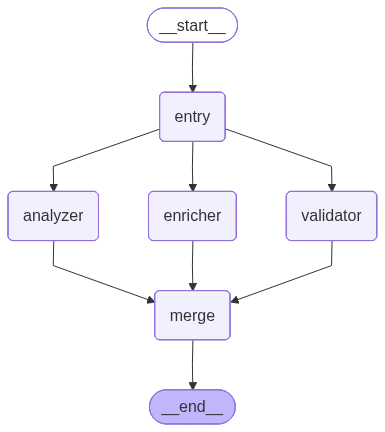

In [43]:
graph_2 = build_fanout_graph()
display(Image(graph_2.get_graph().draw_mermaid_png()))

In [46]:
run_experiment_2()


════════════════════════════════════════════════════════════
  实验二：Fan-out 并行执行
════════════════════════════════════════════════════════════
  图结构：entry → [analyzer, enricher, validator] → merge
  期望：三个节点并行，validator 最慢但不阻塞其他节点


  [17:26:49.893] ⬇️  entry_fanout    │ 开始处理，准备扇出
  [17:26:49.893] ⬇️  entry_fanout    │ raw_text = '这是一个关于 API 系统的测试文本 123'
  [17:26:49.893] ⬇️  entry_fanout    │ ★ 执行完毕，下一步将触发3个并行节点
  [17:26:49.896] 🔵 analyzer_node   │ 开始执行 (线程:8592)
  [17:26:49.896] 🔵 analyzer_node   │ 读取 raw_text: '这是一个关于 API 系统的测试文本 123'
  [17:26:49.897] 🟡 enricher_node   │ 开始执行 (线程:2172)
  [17:26:49.897] 🟡 enricher_node   │ 读取 raw_text: '这是一个关于 API 系统的测试文本 123'
  [17:26:49.899] 🔴 validator_node  │ 开始执行 (线程:9104)
  [17:26:49.899] 🔴 validator_node  │ 读取 raw_text: '这是一个关于 API 系统的测试文本 123'
  [17:26:49.979] 🟡 enricher_node   │ 丰富完成: {'type': 'enrichment', 'language': 'zh', 'category': '技术', 'timestamp': 1779960409.979765}
  [17:26:50.052] 🔵 analyzer_node   │ 分析完成: {'type': 'analysis', 'word_c

实验三：Fan-in 的等待机制  
目标：理解 LangGraph 内部如何实现"等待所有并行节点"  
关键实验：故意让各节点耗时不同，观察 merge 节点的等待行为  

图结构：  
    start  
      │  
      ├──→ fast_node   (0.05s) ─╮  
      ├──→ medium_node (0.15s) ─┤─→ aggregator → END  
      └──→ slow_node   (0.30s) ─╯  

In [47]:

from langgraph.graph import StateGraph, END
from langchain_core.runnables import RunnableConfig
from typing import TypedDict, Annotated, Optional
import operator
import time

# ══════════════════════════════════════════════════════════════
# State：展示 Reducer 的不同写法
# ══════════════════════════════════════════════════════════════

def keep_last(old: Optional[str], new: Optional[str]) -> str:
    """自定义 Reducer：保留最新值（与直接赋值不同的是，这是显式的）"""
    return new if new is not None else old

def merge_dicts(old: dict, new: dict) -> dict:
    """自定义 Reducer：合并字典"""
    result = {**(old or {}), **(new or {})}
    return result

class FaninState(TypedDict):
    # 触发信号
    trigger: str
    
    # 并行节点的结果 —— 每个节点写入不同的 key，所以无需 Reducer
    fast_result:   Optional[str]   # 只有 fast_node 写这个
    medium_result: Optional[str]   # 只有 medium_node 写这个
    slow_result:   Optional[str]   # 只有 slow_node 写这个
    
    # 共享的追加列表 —— 多个节点都写，必须 Reducer
    completion_order: Annotated[list, operator.add]
    
    # 共享的字典 —— 使用自定义 Reducer
    node_metadata: Annotated[dict, merge_dicts]
    
    # 执行追踪
    execution_log: Annotated[list, operator.add]
    
    # 最终结果
    aggregated: str

WALL_CLOCK_START = 0  # 全局起始时间

def elapsed() -> str:
    return f"+{(time.time() - WALL_CLOCK_START)*1000:.0f}ms"

# ══════════════════════════════════════════════════════════════
# 节点：故意设计不同耗时
# ══════════════════════════════════════════════════════════════

def start_node(state: FaninState, config: RunnableConfig) -> dict:
    global WALL_CLOCK_START
    WALL_CLOCK_START = time.time()
    
    print(f"  [{elapsed()}] 🟢 start_node    │ 触发扇出，3个节点即将并行")
    return {
        "execution_log": [{"node": "start", "elapsed": elapsed()}],
    }

def fast_node(state: FaninState, config: RunnableConfig) -> dict:
    """最快的节点：50ms"""
    print(f"  [{elapsed()}] ⚡ fast_node     │ 开始 (预计50ms)")
    
    time.sleep(0.05)
    done_at = elapsed()
    
    print(f"  [{done_at}] ⚡ fast_node     │ ✓ 完成！（最早完成，但等待其他人）")
    
    return {
        "fast_result": "fast_done",
        "completion_order": ["fast"],
        "node_metadata": {"fast": {"done_at": done_at, "duration_ms": 50}},
        "execution_log": [{"node": "fast", "elapsed": done_at}],
    }

def medium_node(state: FaninState, config: RunnableConfig) -> dict:
    """中等速度：150ms"""
    print(f"  [{elapsed()}] 🚶 medium_node   │ 开始 (预计150ms)")
    
    time.sleep(0.15)
    done_at = elapsed()
    
    print(f"  [{done_at}] 🚶 medium_node   │ ✓ 完成！")
    
    return {
        "medium_result": "medium_done",
        "completion_order": ["medium"],
        "node_metadata": {"medium": {"done_at": done_at, "duration_ms": 150}},
        "execution_log": [{"node": "medium", "elapsed": done_at}],
    }

def slow_node(state: FaninState, config: RunnableConfig) -> dict:
    """最慢的节点：300ms —— 整个 SuperStep 等它"""
    print(f"  [{elapsed()}] 🐢 slow_node     │ 开始 (预计300ms，是瓶颈)")
    
    time.sleep(0.30)
    done_at = elapsed()
    
    print(f"  [{done_at}] 🐢 slow_node     │ ✓ 完成！（最慢，解锁 aggregator）")
    
    return {
        "slow_result": "slow_done",
        "completion_order": ["slow"],
        "node_metadata": {"slow": {"done_at": done_at, "duration_ms": 300}},
        "execution_log": [{"node": "slow", "elapsed": done_at}],
    }

def aggregator_node(state: FaninState, config: RunnableConfig) -> dict:
    """
    ★ Fan-in 节点：等所有三个节点完成才执行
    ★ 此时 completion_order 一定包含所有三个节点的结果
    ★ 顺序由完成时间决定（Reducer 追加的顺序）
    """
    done_at = elapsed()
    print(f"\n  [{done_at}] ✅ aggregator    │ 所有节点完成，开始聚合")
    print(f"  [{done_at}] ✅ aggregator    │ 完成顺序: {state['completion_order']}")
    print(f"  [{done_at}] ✅ aggregator    │ fast_result:   {state['fast_result']}")
    print(f"  [{done_at}] ✅ aggregator    │ medium_result: {state['medium_result']}")
    print(f"  [{done_at}] ✅ aggregator    │ slow_result:   {state['slow_result']}")
    
    # 验证所有结果都存在
    all_done = all([
        state["fast_result"] == "fast_done",
        state["medium_result"] == "medium_done",
        state["slow_result"] == "slow_done",
    ])
    
    summary = (
        f"聚合完成 | 完成顺序: {' → '.join(state['completion_order'])} | "
        f"全部完成: {'✓' if all_done else '✗'}"
    )
    
    print(f"  [{done_at}] ✅ aggregator    │ {summary}")
    
    return {
        "aggregated": summary,
        "execution_log": [{"node": "aggregator", "elapsed": done_at}],
    }

# ══════════════════════════════════════════════════════════════
# 构建 Graph
# ══════════════════════════════════════════════════════════════

def build_fanin_graph():
    builder = StateGraph(FaninState)
    
    builder.add_node("start",      start_node)
    builder.add_node("fast",       fast_node)
    builder.add_node("medium",     medium_node)
    builder.add_node("slow",       slow_node)
    builder.add_node("aggregator", aggregator_node)
    
    builder.set_entry_point("start")
    
    # Fan-out
    builder.add_edge("start",  "fast")
    builder.add_edge("start",  "medium")
    builder.add_edge("start",  "slow")
    
    # Fan-in（LangGraph 自动实现等待机制）
    builder.add_edge("fast",   "aggregator")
    builder.add_edge("medium", "aggregator")
    builder.add_edge("slow",   "aggregator")
    
    builder.add_edge("aggregator", END)
    
    return builder.compile()

# ══════════════════════════════════════════════════════════════
# 运行实验
# ══════════════════════════════════════════════════════════════

def run_experiment_3():
    print("\n" + "═"*60)
    print("  实验三：Fan-in 等待机制")
    print("═"*60)
    print("  关键问题：fast_node(50ms) 完成后，能否提前进入 aggregator？")
    print("  答案：不能。aggregator 必须等 slow_node(300ms) 完成")
    print()
    
    graph = build_fanin_graph()
    
    start = time.time()
    result = graph.invoke({
        "trigger": "test",
        "fast_result": None,
        "medium_result": None,
        "slow_result": None,
        "completion_order": [],
        "node_metadata": {},
        "execution_log": [],
        "aggregated": "",
    })
    
    total = time.time() - start
    
    print(f"\n  总耗时: {total:.3f}s ≈ slow_node 的 300ms（并行的效果）")
    print(f"  如果串行: {0.05+0.15+0.30:.2f}s")
    print(f"  加速比:   {(0.05+0.15+0.30)/total:.1f}x")
    print(f"\n  节点元数据（custom Reducer 合并结果）:")
    for name, meta in result["node_metadata"].items():
        print(f"    {name}: {meta}")

run_experiment_3()


════════════════════════════════════════════════════════════
  实验三：Fan-in 等待机制
════════════════════════════════════════════════════════════
  关键问题：fast_node(50ms) 完成后，能否提前进入 aggregator？
  答案：不能。aggregator 必须等 slow_node(300ms) 完成

  [+0ms] 🟢 start_node    │ 触发扇出，3个节点即将并行
  [+3ms] ⚡ fast_node     │ 开始 (预计50ms)
  [+4ms] 🚶 medium_node   │ 开始 (预计150ms)
  [+6ms] 🐢 slow_node     │ 开始 (预计300ms，是瓶颈)
  [+63ms] ⚡ fast_node     │ ✓ 完成！（最早完成，但等待其他人）
  [+162ms] 🚶 medium_node   │ ✓ 完成！
  [+309ms] 🐢 slow_node     │ ✓ 完成！（最慢，解锁 aggregator）

  [+309ms] ✅ aggregator    │ 所有节点完成，开始聚合
  [+309ms] ✅ aggregator    │ 完成顺序: ['fast', 'medium', 'slow']
  [+309ms] ✅ aggregator    │ fast_result:   fast_done
  [+309ms] ✅ aggregator    │ medium_result: medium_done
  [+309ms] ✅ aggregator    │ slow_result:   slow_done
  [+309ms] ✅ aggregator    │ 聚合完成 | 完成顺序: fast → medium → slow | 全部完成: ✓

  总耗时: 0.321s ≈ slow_node 的 300ms（并行的效果）
  如果串行: 0.50s
  加速比:   1.6x

  节点元数据（custom Reducer 合并结果）:
    fast: {'done_at': '+63ms